## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read csv file

In [8]:
df = pd.read_csv('/content/drive/MyDrive/ML/indian_railway_failure.csv')
df.head()

,train_id,region,season,train_type,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,...,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,failure_type,maintenance_required,failure_severity,risk_score
0,1,Northern Railway,Monsoon,Passenger,25,68.378675,128246,23.6,57.8,50.3,...,89.0,22.80,16,94.8,96.3,32.00,NaN,0,NaN,58.9
1,2,Western Railway,Summer,Passenger,4,71.893467,60105,29.5,56.0,7.1,...,91.8,25.22,271,36.5,52.8,6.70,Bearing Failure,1,Medium,75.3
2,3,South Central Railway,Summer,Metro,29,71.066133,36621,32.2,43.3,4.5,...,86.2,21.84,12,100.0,95.8,5.58,Track Defect,1,Low,62.5
3,4,Eastern Railway,Summer,Freight,19,50.082049,33287,37.8,47.0,5.4,...,97.5,24.91,67,98.8,89.5,0.70,Bearing Failure,1,Low,50.0
4,5,Northern Railway,Summer,Freight,31,44.387655,11723,38.4,61.0,1.2,...,89.0,23.68,235,37.4,44.9,4.20,NaN,0,NaN,97.1


## Data Cleaning and Preprocessing

In [9]:
df.shape

(100000, 26)

In [10]:
df.columns

Index(['train_id', 'region', 'season', 'train_type', 'train_age_years',
       'average_speed_kmph', 'distance_travelled_km', 'ambient_temperature_c',
       'humidity_percent', 'rainfall_mm', 'wheel_wear_percent',
       'track_vibration_level', 'rail_wear_mm', 'bearing_temperature_c',
       'axle_temperature_c', 'brake_pad_wear_percent', 'brake_pressure_psi',
       'battery_voltage', 'last_maintenance_days', 'sensor_health_index',
       'inspection_score', 'delay_minutes', 'failure_type',
       'maintenance_required', 'failure_severity', 'risk_score'],
      dtype='object')

In [11]:
df.dtypes

train_id                    int64
region                     object
season                     object
train_type                 object
train_age_years             int64
average_speed_kmph        float64
distance_travelled_km       int64
ambient_temperature_c     float64
humidity_percent          float64
rainfall_mm               float64
wheel_wear_percent        float64
track_vibration_level     float64
rail_wear_mm              float64
bearing_temperature_c     float64
axle_temperature_c        float64
brake_pad_wear_percent    float64
brake_pressure_psi        float64
battery_voltage           float64
last_maintenance_days       int64
sensor_health_index       float64
inspection_score          float64
delay_minutes             float64
failure_type               object
maintenance_required        int64
failure_severity           object
risk_score                float64
dtype: object

In [12]:
df.isnull().sum()

train_id                      0
region                        0
season                        0
train_type                    0
train_age_years               0
average_speed_kmph            0
distance_travelled_km         0
ambient_temperature_c         0
humidity_percent           5000
rainfall_mm                8000
wheel_wear_percent         3000
track_vibration_level      6000
rail_wear_mm                  0
bearing_temperature_c      7000
axle_temperature_c            0
brake_pad_wear_percent        0
brake_pressure_psi            0
battery_voltage            4000
last_maintenance_days         0
sensor_health_index           0
inspection_score              0
delay_minutes                 0
failure_type              69217
maintenance_required          0
failure_severity          69217
risk_score                    0
dtype: int64

In [13]:
def count_per_null(data):  # data = df
    nv = data.isnull().sum()  #nv = null value
    nv = nv[nv>0]    # filter all null values > 0
    nv_df = pd.DataFrame({'Feature':nv.index,'Null_Count':nv.values,
                         'Null%': (nv.values/data.shape[0])*100})
    nv_df = nv_df.sort_values('Null%',ascending=False)  # desc order
    return nv_df

In [14]:
count_per_null(df)

,Feature,Null_Count,Null%
6,failure_type,69217,69.217
7,failure_severity,69217,69.217
1,rainfall_mm,8000,8.000
4,bearing_temperature_c,7000,7.000
3,track_vibration_level,6000,6.000
0,humidity_percent,5000,5.000
5,battery_voltage,4000,4.000
2,wheel_wear_percent,3000,3.000


In [15]:
num_cols = df.dtypes[df.dtypes!='object'].index
cat_cols = df.dtypes[df.dtypes=='object'].index
print(num_cols)
print(cat_cols)

Index(['train_id', 'train_age_years', 'average_speed_kmph',
       'distance_travelled_km', 'ambient_temperature_c', 'humidity_percent',
       'rainfall_mm', 'wheel_wear_percent', 'track_vibration_level',
       'rail_wear_mm', 'bearing_temperature_c', 'axle_temperature_c',
       'brake_pad_wear_percent', 'brake_pressure_psi', 'battery_voltage',
       'last_maintenance_days', 'sensor_health_index', 'inspection_score',
       'delay_minutes', 'maintenance_required', 'risk_score'],
      dtype='object')
Index(['region', 'season', 'train_type', 'failure_type', 'failure_severity'], dtype='object')


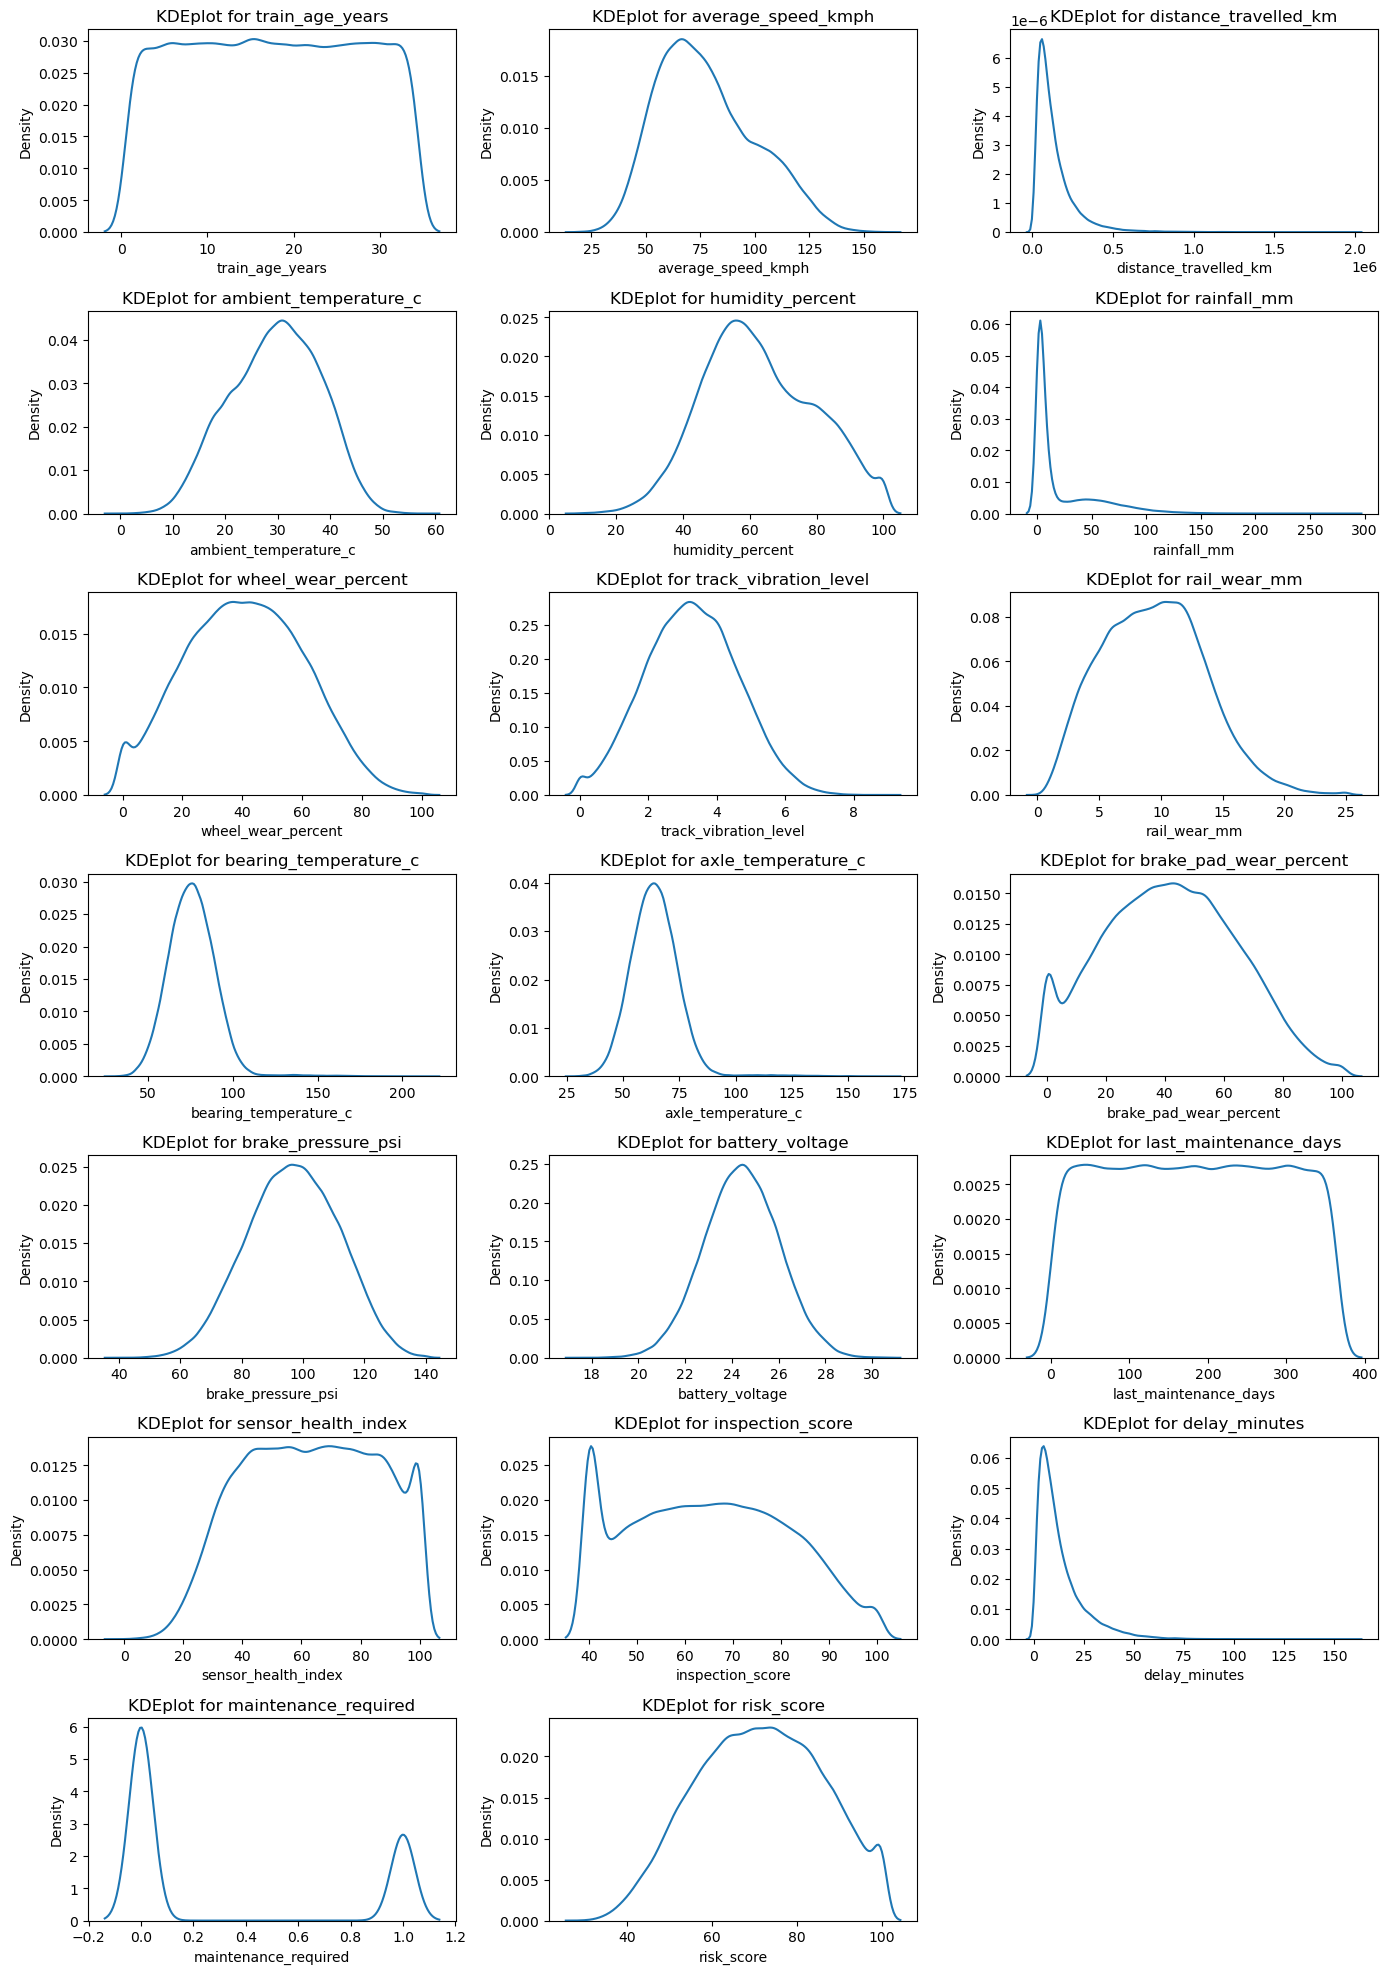

In [16]:
cols = num_cols[1:]
plt.figure(figsize=(14,20))
for i in range(len(cols)):
  plt.subplot(7,3,i+1)
  sns.kdeplot(data=df,x=cols[i])
  plt.title(f'KDEplot for {cols[i]}')
plt.tight_layout()
plt.show()

In [17]:
df['failure_type'].value_counts()

failure_type
Track Defect       16236
Signal Failure      4221
Brake Failure       4194
Wheel Defect        3164
Bearing Failure     2968
Name: count, dtype: int64

In [18]:
df['failure_severity'].value_counts()

failure_severity
Low         14041
Medium       9211
High         5407
Critical     2124
Name: count, dtype: int64

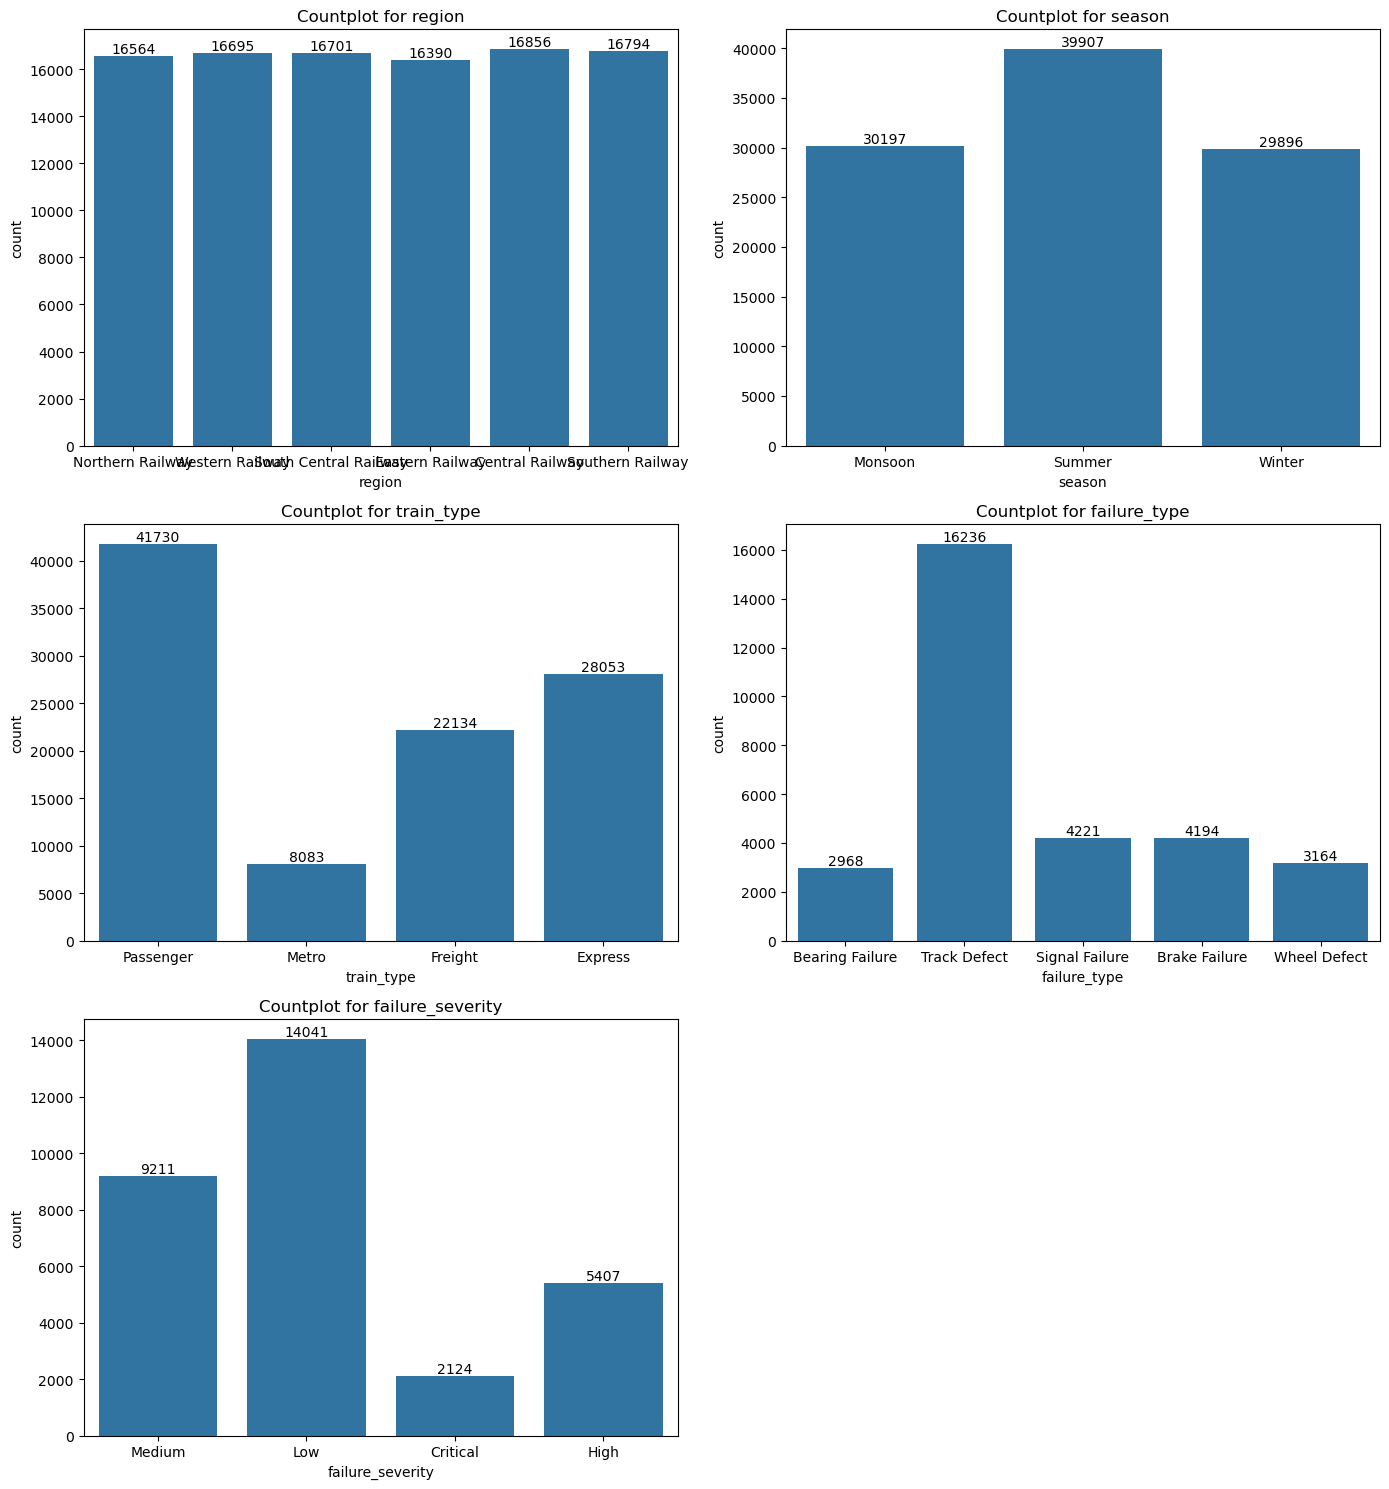

In [19]:
cols = cat_cols
plt.figure(figsize=(14,15))
for i in range(len(cols)):
  plt.subplot(3,2,i+1)
  ax = sns.countplot(data=df,x=cols[i])
  ax.bar_label(ax.containers[0])
  plt.title(f'Countplot for {cols[i]}')
plt.tight_layout()
plt.show()

In [20]:
df.groupby(['failure_severity','failure_type'])['failure_type'].count()

failure_severity  failure_type   
Critical          Bearing Failure     203
                  Brake Failure       286
                  Signal Failure      296
                  Track Defect       1117
                  Wheel Defect        222
High              Bearing Failure     518
                  Brake Failure       767
                  Signal Failure      740
                  Track Defect       2841
                  Wheel Defect        541
Low               Bearing Failure    1361
                  Brake Failure      1864
                  Signal Failure     1916
                  Track Defect       7450
                  Wheel Defect       1450
Medium            Bearing Failure     886
                  Brake Failure      1277
                  Signal Failure     1269
                  Track Defect       4828
                  Wheel Defect        951
Name: failure_type, dtype: int64

In [21]:
df.groupby(['season','failure_type'])['failure_type'].count()

season   failure_type   
Monsoon  Bearing Failure     882
         Brake Failure      1245
         Signal Failure     1974
         Track Defect       4787
         Wheel Defect        896
Summer   Bearing Failure    1204
         Brake Failure      1652
         Signal Failure     1282
         Track Defect       6555
         Wheel Defect       1315
Winter   Bearing Failure     882
         Brake Failure      1297
         Signal Failure      965
         Track Defect       4894
         Wheel Defect        953
Name: failure_type, dtype: int64

In [22]:
df.groupby(['train_type','failure_type'])['failure_type'].count()

train_type  failure_type   
Express     Bearing Failure     840
            Brake Failure      1239
            Signal Failure     1131
            Track Defect       4580
            Wheel Defect        858
Freight     Bearing Failure     639
            Brake Failure       927
            Signal Failure      963
            Track Defect       3566
            Wheel Defect        668
Metro       Bearing Failure     237
            Brake Failure       315
            Signal Failure      344
            Track Defect       1349
            Wheel Defect        254
Passenger   Bearing Failure    1252
            Brake Failure      1713
            Signal Failure     1783
            Track Defect       6741
            Wheel Defect       1384
Name: failure_type, dtype: int64

In [23]:
fs_fv = np.random.choice(['Low','Medium','High','Critical'],size=69217,p=[0.46,0.30,0.17,0.07])
fc_nv_index = df[df['failure_severity'].isnull()].index
print(len(fc_nv_index),len(fs_fv))

69217 69217


In [24]:
df.loc[fc_nv_index,'failure_severity'] = fs_fv

In [25]:
#df['failure_severity'].value_counts(normalize=True)

In [26]:
ft_fv = np.random.choice(['Track Defect','Signal Failure','Brake Failure',
                          'Wheel Defect','Bearing Failure'],size=69217,p=[0.52,0.14,0.14,0.10,0.10])
ft_nv_index = df[df['failure_type'].isnull()].index
print(len(ft_nv_index),len(ft_fv))

69217 69217


In [27]:
df.loc[ft_nv_index,'failure_type'] = ft_fv

In [28]:
nv = df.isnull().sum()
nv = nv[nv>0]
nv

humidity_percent         5000
rainfall_mm              8000
wheel_wear_percent       3000
track_vibration_level    6000
bearing_temperature_c    7000
battery_voltage          4000
dtype: int64

## Model Development 

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

In [30]:
x = df.drop(['train_id','failure_severity'],axis=1)
y = df['failure_severity']
print(x.shape)
print(y.shape)

(100000, 24)
(100000,)


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(70000, 24) (70000,)
(30000, 24) (30000,)


In [33]:
df[num_cols].head()

,train_id,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,wheel_wear_percent,track_vibration_level,rail_wear_mm,...,axle_temperature_c,brake_pad_wear_percent,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,maintenance_required,risk_score
0,1,25,68.378675,128246,23.6,57.8,50.3,64.4,4.00,8.67,...,125.1,65.5,89.0,22.80,16,94.8,96.3,32.00,0,58.9
1,2,4,71.893467,60105,29.5,56.0,7.1,11.5,1.37,6.13,...,54.3,29.7,91.8,25.22,271,36.5,52.8,6.70,1,75.3
2,3,29,71.066133,36621,32.2,43.3,4.5,84.8,6.69,14.20,...,69.5,64.1,86.2,21.84,12,100.0,95.8,5.58,1,62.5
3,4,19,50.082049,33287,37.8,47.0,5.4,32.0,2.32,9.54,...,59.9,49.4,97.5,24.91,67,98.8,89.5,0.70,1,50.0
4,5,31,44.387655,11723,38.4,61.0,1.2,70.7,4.23,11.65,...,72.4,57.5,89.0,23.68,235,37.4,44.9,4.20,0,97.1


In [34]:
num_pipeline = Pipeline([
    ('Num_Imputer',SimpleImputer(strategy='median')),
    ('Scaling',StandardScaler())
])

cat_pipeline = Pipeline([
    ('Dummy variable Creation',OneHotEncoder())
])

In [35]:
cat_cols_encode = ['region', 'season', 'train_type', 'failure_type']

In [36]:
preprocessor = ColumnTransformer([
    ('num',num_pipeline,num_cols[1:]),
    ('cat',cat_pipeline,cat_cols_encode)
])

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler

In [41]:
from sklearn.metrics import *

def eval_model(ytest,ypred):
  print(confusion_matrix(ytest,ypred))
  print(classification_report(ytest,ypred))
  print(accuracy_score(ytest,ypred))

### Logistic Regression

In [195]:
lr_pl = ImbPipeline([
    ('preprocessor',preprocessor),
     ('Handle Imbalance',SMOTE()),
    ('LogReg',LogisticRegression(max_iter=100000))
])

In [200]:
lr_pl.fit(x_train,y_train)
ypred_lr = lr_pl.predict(x_test)
eval_model(y_test,ypred_lr)

[[ 673  486  541  383]
 [1490 1394 1374  997]
 [4101 3501 3371 2662]
 [2733 2387 2225 1682]]
              precision    recall  f1-score   support

    Critical       0.07      0.32      0.12      2083
        High       0.18      0.27      0.21      5255
         Low       0.45      0.25      0.32     13635
      Medium       0.29      0.19      0.23      9027

    accuracy                           0.24     30000
   macro avg       0.25      0.26      0.22     30000
weighted avg       0.33      0.24      0.26     30000

0.23733333333333334


### Random Forest

In [42]:
rf_pl = ImbPipeline([
    ('preprocessor',preprocessor),
    ('Handle Imbalance',SMOTE()),
    ('RF',RandomForestClassifier(n_estimators = 90,criterion='gini',max_depth=7,min_samples_split=10))
])

In [201]:
rf_pl.fit(x_train,y_train)
ypred_rf = rf_pl.predict(x_test)
eval_model(y_test,ypred_rf)

[[    0     0  2078     5]
 [    0     0  5238    17]
 [    0     0 13592    43]
 [    0     1  8991    35]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00      2083
        High       0.00      0.00      0.00      5255
         Low       0.45      1.00      0.62     13635
      Medium       0.35      0.00      0.01      9027

    accuracy                           0.45     30000
   macro avg       0.20      0.25      0.16     30000
weighted avg       0.31      0.45      0.29     30000

0.4542333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Decision Tree

In [205]:
dt_pl = ImbPipeline([
    ('preprocessor',preprocessor),
    ('Handle Imbalance',SMOTE()),
    ('DT_Cls',DecisionTreeClassifier(criterion='entropy',max_depth=6,min_samples_split=8))
])

In [206]:
dt_pl.fit(x_train,y_train)
ypred_dt = dt_pl.predict(x_test)
eval_model(y_test,ypred_dt)

[[    0     5  2078     0]
 [    0    19  5236     0]
 [    1    36 13598     0]
 [    1    20  9006     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00      2083
        High       0.24      0.00      0.01      5255
         Low       0.45      1.00      0.62     13635
      Medium       0.00      0.00      0.00      9027

    accuracy                           0.45     30000
   macro avg       0.17      0.25      0.16     30000
weighted avg       0.25      0.45      0.29     30000

0.4539


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### KNeighborsClassifier

In [207]:
knn_pl = ImbPipeline([
    ('preprocessor',preprocessor),
    ('Handle Imbalance',SMOTE()),
    ('KNN_Cls',KNeighborsClassifier(n_neighbors=11))
])

In [208]:
knn_pl.fit(x_train,y_train)
ypred_knn = knn_pl.predict(x_test)
eval_model(y_test,ypred_knn)

[[ 766  685  221  411]
 [1853 1732  562 1108]
 [4830 4485 1579 2741]
 [3235 3050  972 1770]]
              precision    recall  f1-score   support

    Critical       0.07      0.37      0.12      2083
        High       0.17      0.33      0.23      5255
         Low       0.47      0.12      0.19     13635
      Medium       0.29      0.20      0.24      9027

    accuracy                           0.19     30000
   macro avg       0.25      0.25      0.19     30000
weighted avg       0.34      0.19      0.20     30000

0.1949


## Save the models

In [209]:
import pickle

In [210]:
path = "/content/drive/MyDrive/ML"
pickle.dump(lr_pl,open('/content/drive/MyDrive/ML/lr.pkl','wb'))
pickle.dump(rf_pl,open('/content/drive/MyDrive/ML/rf.pkl','wb'))
pickle.dump(knn_pl,open('/content/drive/MyDrive/ML/knn.pkl','wb'))
pickle.dump(dt_pl,open('/content/drive/MyDrive/ML/dt.pkl','wb'))


In [211]:
x_train.describe()

,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,wheel_wear_percent,track_vibration_level,rail_wear_mm,bearing_temperature_c,axle_temperature_c,brake_pad_wear_percent,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,maintenance_required,risk_score
count,70000.000000,70000.000000,7.000000e+04,70000.000000,66481.000000,64325.000000,67860.000000,65754.000000,70000.000000,65125.000000,70000.000000,70000.000000,70000.000000,67187.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,17.511271,77.872660,1.369671e+05,29.484364,62.805053,21.411356,40.812583,3.268689,9.424711,76.008060,64.103221,41.724776,96.761891,24.411622,182.346929,63.370354,64.864671,12.958999,0.308614,71.439377
std,9.807552,22.461806,1.305123e+05,8.454376,16.686005,30.560739,19.730290,1.350338,4.142804,14.224098,10.957175,22.551044,14.851687,1.602280,105.174764,22.075345,16.377738,11.795947,0.461925,14.710881
min,1.000000,20.000000,5.000000e+03,-0.400000,10.000000,0.000000,0.000000,0.000000,0.380000,28.800000,27.900000,0.000000,39.900000,17.380000,1.000000,0.100000,40.000000,0.000000,0.000000,30.000000
25%,9.000000,60.773631,5.757475e+04,23.400000,50.700000,2.300000,26.200000,2.320000,6.250000,66.600000,57.100000,24.700000,86.400000,23.330000,92.000000,45.400000,51.300000,4.900000,0.000000,60.400000
50%,17.000000,74.659448,9.875450e+04,29.900000,61.100000,6.000000,40.700000,3.260000,9.360000,75.500000,63.700000,41.500000,96.900000,24.410000,182.000000,63.600000,64.600000,9.300000,0.000000,71.500000
75%,26.000000,92.839064,1.705835e+05,35.800000,75.100000,32.200000,55.200000,4.200000,12.270000,84.500000,70.400000,58.100000,107.400000,25.500000,274.000000,81.900000,77.700000,17.000000,1.000000,82.600000
max,34.000000,160.000000,2.000000e+06,58.200000,100.000000,287.800000,100.000000,8.960000,25.000000,217.440000,169.920000,100.000000,140.000000,30.670000,364.000000,100.000000,100.000000,160.020000,1.000000,100.000000
